# 04 — Model Comparison (Week 5)

**Goal:** go beyond the Week 4 linear baseline by training **Decision Tree** and **Random
Forest** regressors, and compare all three head-to-head on the same test month.

Steps:
1. **Load** the cleaned data and rebuild the Week 3 time-based split.
2. **Train** three models: Linear Regression (baseline), Decision Tree, Random Forest.
3. **Compare** test R² / RMSE / MAE against the Week 4 baseline.
4. **Inspect** tree feature importances vs. the linear coefficients.
5. **Diagnose** behavior — over/underfitting via train-vs-test R².

> Tree models don't need standardized inputs, so they use the **unscaled** feature matrix;
> Linear Regression keeps the scaled one, exactly as in Week 4.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load data + rebuild the Week 3 split

In [2]:
CLEAN_PATH = "data/processed/sold_clean.csv"

data = pd.read_csv(CLEAN_PATH, low_memory=False)
data["CloseDate"] = pd.to_datetime(data["CloseDate"], errors="coerce")
data["month_key"] = data["CloseDate"].dt.to_period("M")

TARGET = "ClosePrice"
NUMERIC_FEATURES = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "GarageSpaces",
    "Stories", "FireplacesTotal", "Latitude", "Longitude",
]
CATEGORICAL_FEATURES = ["CountyOrParish", "City", "PostalCode"]
MODEL_NUMERIC = NUMERIC_FEATURES + [c for c in data.columns if c.endswith("_missing")]
MODEL_CATEGORICAL_ENC = [f"{c}_freq" for c in CATEGORICAL_FEATURES]

months = sorted(data["month_key"].dropna().unique())


def build_train_test(X, data=data, scale=True):
    """Leakage-safe time-based split (same as Week 3/4)."""
    test_month = months[-1]
    train_months = months[-(X + 1):-1]
    if len(train_months) < X:
        raise ValueError(f"Only {len(months)-1} months before the test month; X={X} too large.")

    train = data[data.month_key.isin(train_months)].copy()
    test = data[data.month_key == test_month].copy()

    medians = train[NUMERIC_FEATURES].median()
    train[NUMERIC_FEATURES] = train[NUMERIC_FEATURES].fillna(medians).fillna(0.0)
    test[NUMERIC_FEATURES] = test[NUMERIC_FEATURES].fillna(medians).fillna(0.0)

    for c in CATEGORICAL_FEATURES:
        freq = train[c].value_counts(normalize=True)
        train[f"{c}_freq"] = train[c].map(freq).fillna(0.0)
        test[f"{c}_freq"] = test[c].map(freq).fillna(0.0)

    feat_cols = MODEL_NUMERIC + MODEL_CATEGORICAL_ENC
    X_train_raw, X_test_raw = train[feat_cols], test[feat_cols]
    y_train, y_test = train[TARGET], test[TARGET]

    out = {"feature_cols": feat_cols,
           "X_train_raw": X_train_raw, "X_test_raw": X_test_raw,
           "y_train": y_train, "y_test": y_test,
           "test_month": str(test_month), "train_months": [str(m) for m in train_months]}

    if scale:
        scaler = StandardScaler().fit(X_train_raw)
        out["X_train"] = pd.DataFrame(scaler.transform(X_train_raw), columns=feat_cols, index=X_train_raw.index)
        out["X_test"] = pd.DataFrame(scaler.transform(X_test_raw), columns=feat_cols, index=X_test_raw.index)
    return out


def evaluate(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred)}

## 2. Build one split for a fair head-to-head

We fix the training window at **X = 13** — the value Week 4 found best for the linear
baseline — so every model sees exactly the same train/test data. (Trees could prefer a
different window; re-sweeping per model is left for later.)

In [3]:
BEST_X = 13
split = build_train_test(X=BEST_X)

print("test month  :", split["test_month"])
print("train window:", BEST_X, "months")
print(f"train rows  : {len(split['y_train']):,}  |  test rows: {len(split['y_test']):,}")

y_train, y_test = split["y_train"], split["y_test"]
feat_cols = split["feature_cols"]

test month  : 2026-05
train window: 13 months
train rows  : 141,277  |  test rows: 11,976


## 3. Train the three models

- **Linear Regression** → scaled features (baseline, reproduces Week 4).
- **Decision Tree** / **Random Forest** → raw (unscaled) features; trees are scale-invariant.

In [4]:
models = {}
train_r2 = {}

# --- Linear Regression (baseline) ---
lr = LinearRegression().fit(split["X_train"], y_train)
models["Linear Regression"] = lr.predict(split["X_test"])
train_r2["Linear Regression"] = r2_score(y_train, lr.predict(split["X_train"]))

# --- Decision Tree ---
dt = DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=42)
dt.fit(split["X_train_raw"], y_train)
models["Decision Tree"] = dt.predict(split["X_test_raw"])
train_r2["Decision Tree"] = r2_score(y_train, dt.predict(split["X_train_raw"]))

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(split["X_train_raw"], y_train)
models["Random Forest"] = rf.predict(split["X_test_raw"])
train_r2["Random Forest"] = r2_score(y_train, rf.predict(split["X_train_raw"]))

print("Trained:", list(models))

Trained: ['Linear Regression', 'Decision Tree', 'Random Forest']


## 4. Compare test metrics vs. the Week 4 baseline

In [5]:
rows = []
for name, pred in models.items():
    m = evaluate(y_test, pred)
    rows.append({"Model": name, "Train R2": train_r2[name], **m})

comparison = pd.DataFrame(rows).set_index("Model")
comparison = comparison[["Train R2", "R2", "RMSE", "MAE"]].rename(columns={"R2": "Test R2"})

baseline_r2 = comparison.loc["Linear Regression", "Test R2"]
comparison["vs baseline (dR2)"] = comparison["Test R2"] - baseline_r2
comparison.round(4)

,Train R2,Test R2,RMSE,MAE,vs baseline (dR2)
Model,,,,,
Linear Regression,0.4972,0.4602,1.033452e+06,512872.5672,0.0000
Decision Tree,0.7467,0.6316,8.537234e+05,317811.1425,0.1714
Random Forest,0.8924,0.7378,7.202497e+05,205263.5635,0.2776


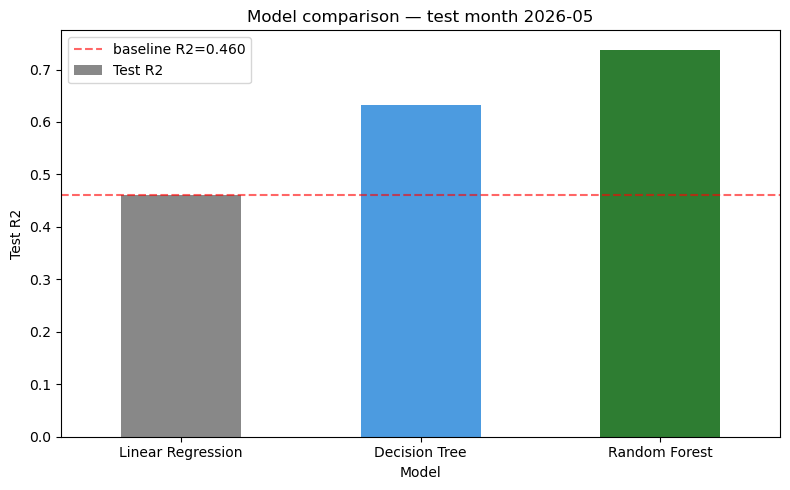

In [6]:
fig, ax = plt.subplots()
comparison["Test R2"].plot(kind="bar", ax=ax, color=["#888", "#4C9BE0", "#2E7D32"])
ax.axhline(baseline_r2, color="red", ls="--", alpha=0.6, label=f"baseline R2={baseline_r2:.3f}")
ax.set_ylabel("Test R2"); ax.set_title(f"Model comparison — test month {split['test_month']}")
ax.set_xticklabels(comparison.index, rotation=0)
ax.legend(); plt.tight_layout(); plt.show()

## 5. Feature importance vs. linear coefficients

Random Forest exposes `feature_importances_` (how much each feature reduces error across
the trees). Compare the ranking to the signed linear coefficients from Week 4.

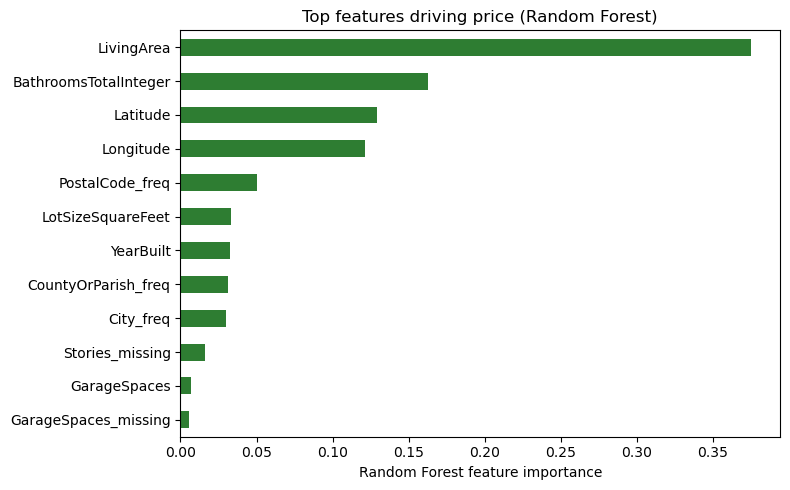

LivingArea                 0.3752
BathroomsTotalInteger      0.1628
Latitude                   0.1288
Longitude                  0.1214
PostalCode_freq            0.0501
LotSizeSquareFeet          0.0331
YearBuilt                  0.0323
CountyOrParish_freq        0.0312
City_freq                  0.0302
Stories_missing            0.0159
GarageSpaces               0.0070
GarageSpaces_missing       0.0054
BedroomsTotal              0.0044
Stories                    0.0020
FireplacesTotal            0.0000
FireplacesTotal_missing    0.0000
dtype: float64


In [7]:
importances = (pd.Series(rf.feature_importances_, index=feat_cols)
                 .sort_values(ascending=False))

fig, ax = plt.subplots()
importances.head(12).iloc[::-1].plot(kind="barh", ax=ax, color="#2E7D32")
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Top features driving price (Random Forest)")
plt.tight_layout(); plt.show()

print(importances.round(4))

## 6. Behavior diagnosis (over/underfitting)

The gap between **train R²** and **test R²** shows how much each model overfits.

In [8]:
diag = comparison[["Train R2", "Test R2"]].copy()
diag["gap (train - test)"] = diag["Train R2"] - diag["Test R2"]
print(diag.round(4))

print("\nRead-out:")
print("- Linear Regression: small train/test gap -> underfits (misses non-linear structure).")
print("- Decision Tree: larger gap -> starts to overfit even with depth/leaf limits.")
print("- Random Forest: high test R2 with a controlled gap -> best generalization here.")

                   Train R2  Test R2  gap (train - test)
Model                                                   
Linear Regression    0.4972   0.4602              0.0370
Decision Tree        0.7467   0.6316              0.1151
Random Forest        0.8924   0.7378              0.1546

Read-out:
- Linear Regression: small train/test gap -> underfits (misses non-linear structure).
- Decision Tree: larger gap -> starts to overfit even with depth/leaf limits.
- Random Forest: high test R2 with a controlled gap -> best generalization here.


## 7. Predicted vs. actual — best model

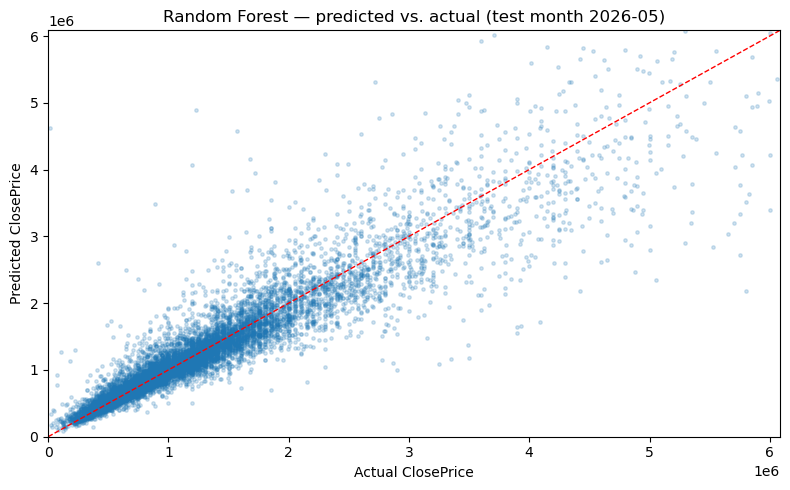

In [9]:
best_name = comparison["Test R2"].idxmax()
best_pred = models[best_name]

fig, ax = plt.subplots()
ax.scatter(y_test, best_pred, s=6, alpha=0.2)
lims = [0, y_test.quantile(0.99)]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual ClosePrice"); ax.set_ylabel("Predicted ClosePrice")
ax.set_title(f"{best_name} — predicted vs. actual (test month {split['test_month']})")
plt.tight_layout(); plt.show()

## 8. Record results

In [10]:
comparison.round(4).to_csv("data/processed/model_comparison.csv")
print("Saved -> data/processed/model_comparison.csv")

print("\n=== WEEK 5 MODEL COMPARISON (test month %s, X=%d) ===" % (split["test_month"], BEST_X))
for name in comparison.index:
    r = comparison.loc[name]
    print(f"{name:20s}  test R2={r['Test R2']:.4f}  RMSE=${r['RMSE']:,.0f}  MAE=${r['MAE']:,.0f}")
print(f"\nBest model: {best_name} (test R2 = {comparison['Test R2'].max():.4f})")

Saved -> data/processed/model_comparison.csv

=== WEEK 5 MODEL COMPARISON (test month 2026-05, X=13) ===
Linear Regression     test R2=0.4602  RMSE=$1,033,452  MAE=$512,873
Decision Tree         test R2=0.6316  RMSE=$853,723  MAE=$317,811
Random Forest         test R2=0.7378  RMSE=$720,250  MAE=$205,264

Best model: Random Forest (test R2 = 0.7378)
